<a href="https://colab.research.google.com/github/amykimkim/nhanes_inferential_2021_23/blob/main/NHANES_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
install.packages('haven')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
install.packages('dplyr')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
install.packages('ggplot2')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [36]:
library(haven)
library(dplyr)
library(ggplot2)

In [6]:
#Question 1: Is there an association between marital status (DMDMARTZ) (married or not married) and education level (DMDEDUC2) (bachelor’s degree or higher vs. less than a bachelor’s degree)?
#Marital status 1 = Married/Living with partner; 2 = Widowed/Divorced/Separated; 3 = Never married)
#need to clean data to rid of 99.0 and 77.0
#clean education level data so that it's categorized into "less than bachelor's" and "bachelor's or higher"
#create contingency table and perform chi-square test


In [44]:
file_path <- '/content/DEMO_L.xpt'

In [45]:
library(dplyr)
demo_data <- read_xpt(file_path)
# Clean and Recode Marital Status (DMDMARTZ)
# Filter out invalid marital status values (77.0 and 99.0)
# Recode DMDMARTZ into two categories: 'Married' (for 1) and 'Not Married' (for 2, 3)
demo_data_cleaned <- demo_data %>%
  filter(!DMDMARTZ %in% c(77, 99)) %>%
  mutate(marital_status = case_when(
    DMDMARTZ == 1 ~ "Married",
    DMDMARTZ %in% c(2, 3) ~ "Not Married",
    TRUE ~ NA_character_ # Handle any other unexpected values as NA
  ))

# Display counts of the new marital_status variable
print("Counts of Marital Status after cleaning and recoding:")
print(table(demo_data_cleaned$marital_status, useNA = "ifany"))

[1] "Counts of Marital Status after cleaning and recoding:"

    Married Not Married        <NA> 
       4136        3647        4141 


In [46]:
# Clean and Recode Education Level (DMDEDUC2)
# Filter out invalid education level values (77.0 and 99.0)
# Recode DMDEDUC2 into two categories: 'Less than Bachelor\'s' (for 1, 2, 3, 4) and 'Bachelor\'s or Higher' (for 5)
demo_data_cleaned <- demo_data_cleaned %>%
  filter(!DMDEDUC2 %in% c(77, 99)) %>%
  mutate(education_level = case_when(
    DMDEDUC2 %in% c(1, 2, 3, 4) ~ "Less than Bachelor's",
    DMDEDUC2 == 5 ~ "Bachelor's or Higher",
    TRUE ~ NA_character_ # Handle any other unexpected values as NA
  ))

# Display counts of the new education_level variable
print("Counts of Education Level after cleaning and recoding:")
print(table(demo_data_cleaned$education_level, useNA = "ifany"))

[1] "Counts of Education Level after cleaning and recoding:"

Bachelor's or Higher Less than Bachelor's                 <NA> 
                2621                 5153                 4150 


In [47]:
# Create a contingency table
contingency_table <- table(demo_data_cleaned$marital_status, demo_data_cleaned$education_level)
print("Contingency Table of Marital Status and Education Level:")
print(contingency_table)

[1] "Contingency Table of Marital Status and Education Level:"
             
              Bachelor's or Higher Less than Bachelor's
  Married                     1631                 2503
  Not Married                  990                 2648


In [48]:
# Perform Chi-Square Test
chi_square_result <- chisq.test(contingency_table)
print("Chi-Square Test Results:")
print(chi_square_result)

[1] "Chi-Square Test Results:"

	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 129.17, df = 1, p-value < 2.2e-16



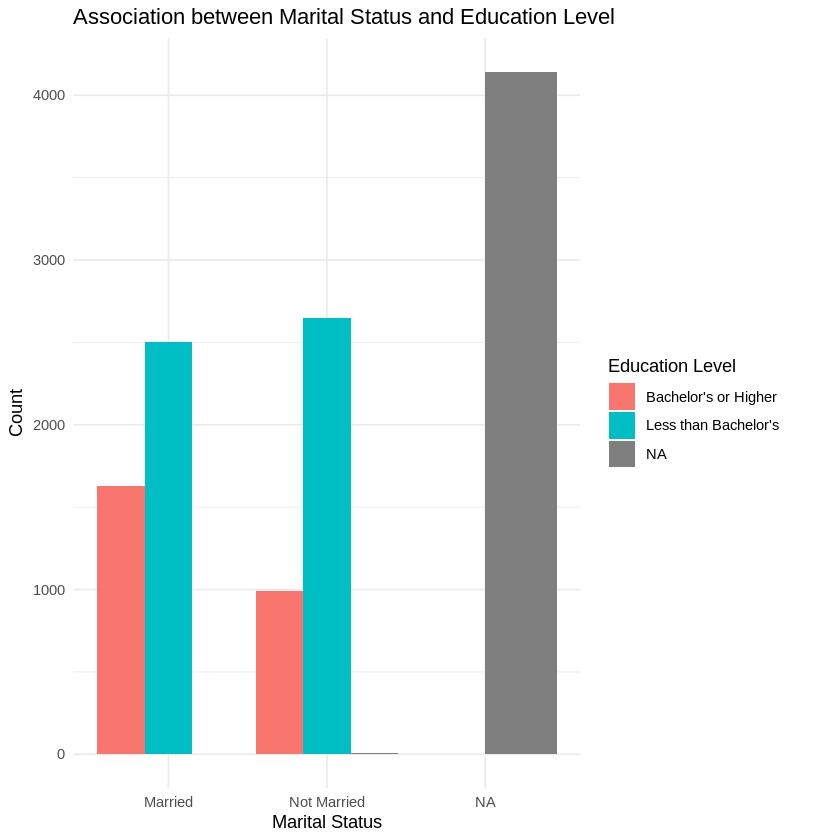

In [49]:
library(ggplot2)
# Visualize the Association
# Generate a grouped bar chart to visualize the relationship between marital status and education level
# and include appropriate labels and a legend for clarity.

ggplot(demo_data_cleaned, aes(x = marital_status, fill = education_level)) +
  geom_bar(position = "dodge") +
  labs(title = "Association between Marital Status and Education Level",
       x = "Marital Status",
       y = "Count",
       fill = "Education Level") +
  theme_minimal()

In [43]:

# Question 2: "Is there a difference in the mean sedentary behavior time between those who are married and those who are not married?"
# 1. Load demographic data and create 'married_status'
# 2. Load physical activity data and clean 'PAD680'
# 3. Merge SEQN, married status, and physical activity


In [26]:
demographics_raw <- read_xpt(file_path)

print("Demographics raw data loaded. First few rows:")
print(head(demographics_raw))

[1] "Demographics raw data loaded. First few rows:"
# A tibble: 6 × 27
    SEQN SDDSRVYR RIDSTATR RIAGENDR RIDAGEYR RIDAGEMN RIDRETH1 RIDRETH3 RIDEXMON
   <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>
1 130378       12        2        1       43       NA        5        6        2
2 130379       12        2        1       66       NA        3        3        2
3 130380       12        2        2       44       NA        2        2        1
4 130381       12        2        2        5       NA        5        7        1
5 130382       12        2        1        2       NA        3        3        2
6 130383       12        1        2        3       NA        2        2       NA
# ℹ 18 more variables: RIDEXAGM <dbl>, DMQMILIZ <dbl>, DMDBORN4 <dbl>,
#   DMDYRUSR <dbl>, DMDEDUC2 <dbl>, DMDMARTZ <dbl>, RIDEXPRG <dbl>,
#   DMDHHSIZ <dbl>, DMDHRGND <dbl>, DMDHRAGZ <dbl>, DMDHREDZ <dbl>,
#   DMDHRMAZ <dbl>, DMDHSEDZ <dbl>, WTINT2YR <dbl>, WTMEC2YR <dbl>,
#   SD

In [27]:
demographics_marital_cleaned <- demographics_raw %>%
  filter(!DMDMARTZ %in% c(77, 99)) %>%
  mutate(marital_status = case_when(
    DMDMARTZ == 1 ~ "Married",
    DMDMARTZ %in% c(2, 3) ~ "Not Married",
    TRUE ~ NA_character_ # Handle any other unexpected values as NA
  ))

print("Counts of Marital Status after cleaning and recoding:")
print(table(demographics_marital_cleaned$marital_status, useNA = "ifany"))

[1] "Counts of Marital Status after cleaning and recoding:"

    Married Not Married        <NA> 
       4136        3647        4141 


In [28]:
physical_activity_raw <- read_xpt('/content/PAQ_L.xpt')

print("Physical Activity Raw Data (first few rows):")
print(head(physical_activity_raw))

print("\nSummary of PAD680 column before cleaning:")
print(summary(physical_activity_raw$PAD680))

[1] "Physical Activity Raw Data (first few rows):"
# A tibble: 6 × 8
    SEQN PAD790Q PAD790U PAD800 PAD810Q PAD810U PAD820 PAD680
   <dbl>   <dbl> <chr>    <dbl>   <dbl> <chr>    <dbl>  <dbl>
1 130378       3 "W"         45       3 "W"         45    360
2 130379       4 "W"         45       3 "W"         45    480
3 130380       1 "W"         20       0 ""          NA    240
4 130384       0 ""          NA       0 ""          NA     60
5 130385       1 "D"         90       1 "W"         60    180
6 130386       1 "W"         30       1 "M"         30    180
[1] "\nSummary of PAD680 column before cleaning:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
      0     180     300     447     480    9999      15 


In [29]:
physical_activity_cleaned <- physical_activity_raw %>%
  filter(!PAD680 %in% c(7777, 9999)) %>% # Filter out invalid codes
  filter(!is.na(PAD680)) # Remove NA values explicitly

print("Physical Activity Cleaned Data (first few rows with PAD680):")
print(head(physical_activity_cleaned %>% select(SEQN, PAD680)))

print("\nSummary of PAD680 column after cleaning:")
print(summary(physical_activity_cleaned$PAD680))

[1] "Physical Activity Cleaned Data (first few rows with PAD680):"
# A tibble: 6 × 2
    SEQN PAD680
   <dbl>  <dbl>
1 130378    360
2 130379    480
3 130380    240
4 130384     60
5 130385    180
6 130386    180
[1] "\nSummary of PAD680 column after cleaning:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0   180.0   300.0   362.2   480.0  1380.0 


In [30]:
merged_data <- left_join(demographics_marital_cleaned, physical_activity_cleaned, by = "SEQN")


In [31]:
analysis_data <- merged_data %>%
  filter(!is.na(marital_status) & !is.na(PAD680))

# Separate PAD680 values into two vectors based on marital status
married_sedentary_time <- analysis_data %>%
  filter(marital_status == "Married") %>%
  pull(PAD680)

not_married_sedentary_time <- analysis_data %>%
  filter(marital_status == "Not Married") %>%
  pull(PAD680)

print("Number of observations for Married group:")
print(length(married_sedentary_time))
print("Number of observations for Not Married group:")
print(length(not_married_sedentary_time))

print("First few values of Married Sedentary Time:")
print(head(married_sedentary_time))
print("First few values of Not Married Sedentary Time:")
print(head(not_married_sedentary_time))

[1] "Number of observations for Married group:"
[1] 4106
[1] "Number of observations for Not Married group:"
[1] 3603
[1] "First few values of Married Sedentary Time:"
[1] 360 480 240 180 180 360
[1] "First few values of Not Married Sedentary Time:"
[1]   60 1200  240  360  960  840


In [32]:
shapiro_married <- shapiro.test(married_sedentary_time)
shapiro_not_married <- shapiro.test(not_married_sedentary_time)

print("Shapiro-Wilk Test for Married Group:")
print(shapiro_married)
print("\nShapiro-Wilk Test for Not Married Group:")
print(shapiro_not_married)

[1] "Shapiro-Wilk Test for Married Group:"

	Shapiro-Wilk normality test

data:  married_sedentary_time
W = 0.9432, p-value < 2.2e-16

[1] "\nShapiro-Wilk Test for Not Married Group:"

	Shapiro-Wilk normality test

data:  not_married_sedentary_time
W = 0.94258, p-value < 2.2e-16



In [33]:
# Question 3: "How do age and marital status affect systolic blood pressure?"


In [50]:
# Load blood pressure data
blood_pressure_raw <- read_xpt('/content/BPXO_L.xpt')


[1] "Blood Pressure Raw Data (first few rows):"
# A tibble: 6 × 12
    SEQN BPAOARM BPAOCSZ BPXOSY1 BPXODI1 BPXOSY2 BPXODI2 BPXOSY3 BPXODI3
   <dbl> <chr>     <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
1 130378 R             4     135      98     131      96     132      94
2 130379 R             4     121      84     117      76     113      76
3 130380 R             4     111      79     112      80     104      76
4 130386 R             4     110      72     120      74     115      75
5 130387 R             4     143      76     136      74     145      78
6 130388 R             5     130      95     128     100     129     104
# ℹ 3 more variables: BPXOPLS1 <dbl>, BPXOPLS2 <dbl>, BPXOPLS3 <dbl>


In [51]:
# Load demographic data
demographics_q3 <- read_xpt('/content/DEMO_L.xpt')


[1] "Demographics Data for Q3 (first few rows):"
# A tibble: 6 × 27
    SEQN SDDSRVYR RIDSTATR RIAGENDR RIDAGEYR RIDAGEMN RIDRETH1 RIDRETH3 RIDEXMON
   <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>
1 130378       12        2        1       43       NA        5        6        2
2 130379       12        2        1       66       NA        3        3        2
3 130380       12        2        2       44       NA        2        2        1
4 130381       12        2        2        5       NA        5        7        1
5 130382       12        2        1        2       NA        3        3        2
6 130383       12        1        2        3       NA        2        2       NA
# ℹ 18 more variables: RIDEXAGM <dbl>, DMQMILIZ <dbl>, DMDBORN4 <dbl>,
#   DMDYRUSR <dbl>, DMDEDUC2 <dbl>, DMDMARTZ <dbl>, RIDEXPRG <dbl>,
#   DMDHHSIZ <dbl>, DMDHRGND <dbl>, DMDHRAGZ <dbl>, DMDHREDZ <dbl>,
#   DMDHRMAZ <dbl>, DMDHSEDZ <dbl>, WTINT2YR <dbl>, WTMEC2YR <dbl>,
#   SDMVS

In [52]:
# Clean and Recode Marital Status (DMDMARTZ)
# Filter out invalid marital status values (77.0 and 99.0)
# Recode DMDMARTZ into two categories: 'Married' (for 1) and 'Not Married' (for 2, 3)
demographics_q3_cleaned <- demographics_q3 %>%
  filter(!DMDMARTZ %in% c(77, 99)) %>%
  mutate(marital_status = case_when(
    DMDMARTZ == 1 ~ "Married",
    DMDMARTZ %in% c(2, 3) ~ "Not Married",
    TRUE ~ NA_character_ # Handle any other unexpected values as NA
  ))

print("Counts of Marital Status after cleaning and recoding for Q3:")
print(table(demographics_q3_cleaned$marital_status, useNA = "ifany"))

[1] "Counts of Marital Status after cleaning and recoding for Q3:"

    Married Not Married        <NA> 
       4136        3647        4141 


In [53]:
# Select relevant columns and merge datasets
# Relevant columns from demographics: SEQN, RIDAGEYR, marital_status
# Relevant columns from blood pressure: SEQN, BPXOSY3 (Systolic Blood Pressure)

analysis_data_q3 <- demographics_q3_cleaned %>%
  select(SEQN, RIDAGEYR, marital_status) %>%
  left_join(blood_pressure_raw %>%
              select(SEQN, BPXOSY3), by = "SEQN") %>%
  filter(!is.na(marital_status) & !is.na(RIDAGEYR) & !is.na(BPXOSY3))

print("Merged and Cleaned Data for Q3 (first few rows):")
print(head(analysis_data_q3))
print("Summary of BPXOSY3 after cleaning:")
print(summary(analysis_data_q3$BPXOSY3))

[1] "Merged and Cleaned Data for Q3 (first few rows):"
# A tibble: 6 × 4
    SEQN RIDAGEYR marital_status BPXOSY3
   <dbl>    <dbl> <chr>            <dbl>
1 130378       43 Married            132
2 130379       66 Married            113
3 130380       44 Married            104
4 130386       34 Married            115
5 130387       68 Not Married        145
6 130388       27 Married            129
[1] "Summary of BPXOSY3 after cleaning:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   62.0   110.0   120.0   122.7   132.0   232.0 


In [54]:
# Perform Multiple Linear Regression
# Convert marital_status to a factor for regression
analysis_data_q3$marital_status <- as.factor(analysis_data_q3$marital_status)

# Create the linear regression model
# BPXOSY3 ~ RIDAGEYR + marital_status
model_q3 <- lm(BPXOSY3 ~ RIDAGEYR + marital_status, data = analysis_data_q3)

# Print the summary of the regression model
print("Multiple Linear Regression Model Summary:")
print(summary(model_q3))

[1] "Multiple Linear Regression Model Summary:"

Call:
lm(formula = BPXOSY3 ~ RIDAGEYR + marital_status, data = analysis_data_q3)

Residuals:
    Min      1Q  Median      3Q     Max 
-63.251 -11.145  -1.461   9.380 106.126 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)               100.81805    0.78468 128.483  < 2e-16 ***
RIDAGEYR                    0.39524    0.01313  30.105  < 2e-16 ***
marital_statusNot Married   1.34197    0.45086   2.976  0.00293 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 17.1 on 5835 degrees of freedom
Multiple R-squared:  0.1345,	Adjusted R-squared:  0.1342 
F-statistic: 453.3 on 2 and 5835 DF,  p-value: < 2.2e-16



In [55]:
# Question 4: "Is there a correlation between self-reported weight and minutes of sedentary behavior?"
# Load in weight_df from WHQ_L.xpt
# Merge the dataframes on 'SEQN'
# Drop rows with missing values in the variables of interest
# Calculate the Pearson correlation coefficient


In [59]:
weight_raw <- read_xpt('/content/WHQ_L.xpt')

print("Weight Raw Data (first few rows):")
print(head(weight_raw))

print("\nSummary of WHD050 column before cleaning:")
print(summary(weight_raw$WHD050))

[1] "Weight Raw Data (first few rows):"
# A tibble: 6 × 5
    SEQN WHD010 WHD020 WHD050 WHQ070
   <dbl>  <dbl>  <dbl>  <dbl>  <dbl>
1 130378     71    190    200      1
2 130379     70    220    220      2
3 130380     60    150    165      1
4 130384     68    204    212      1
5 130385     70    240    240      2
6 130386     68    200    180      2
[1] "\nSummary of WHD050 column before cleaning:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   67.0   145.0   175.0   420.5   214.0  9999.0      15 


In [60]:
weight_cleaned <- weight_raw %>%
  filter(!WHD050 %in% c(7777, 9999)) %>%
  filter(!is.na(WHD050))

print("Weight Cleaned Data (first few rows with WHD050):")
print(head(weight_cleaned %>% select(SEQN, WHD050)))

print("\nSummary of WHD050 column after cleaning:")
print(summary(weight_cleaned$WHD050))

[1] "Weight Cleaned Data (first few rows with WHD050):"
# A tibble: 6 × 2
    SEQN WHD050
   <dbl>  <dbl>
1 130378    200
2 130379    220
3 130380    165
4 130384    212
5 130385    240
6 130386    180
[1] "\nSummary of WHD050 column after cleaning:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   67.0   145.0   175.0   181.5   210.0   530.0 


In [61]:
correlation_data <- left_join(weight_cleaned, physical_activity_cleaned, by = "SEQN")

print("Merged data for correlation analysis (first few rows):")
print(head(correlation_data))
print("Dimensions of the merged data:")
print(dim(correlation_data))

[1] "Merged data for correlation analysis (first few rows):"
# A tibble: 6 × 12
    SEQN WHD010 WHD020 WHD050 WHQ070 PAD790Q PAD790U PAD800 PAD810Q PAD810U
   <dbl>  <dbl>  <dbl>  <dbl>  <dbl>   <dbl> <chr>    <dbl>   <dbl> <chr>  
1 130378     71    190    200      1       3 "W"         45       3 "W"    
2 130379     70    220    220      2       4 "W"         45       3 "W"    
3 130380     60    150    165      1       1 "W"         20       0 ""     
4 130384     68    204    212      1       0 ""          NA       0 ""     
5 130385     70    240    240      2       1 "D"         90       1 "W"    
6 130386     68    200    180      2       1 "W"         30       1 "M"    
# ℹ 2 more variables: PAD820 <dbl>, PAD680 <dbl>
[1] "Dimensions of the merged data:"
[1] 8272   12


In [62]:
correlation_data_filtered <- correlation_data %>%
  filter(!is.na(WHD050) & !is.na(PAD680))

print("Filtered data for correlation analysis (first few rows):")
print(head(correlation_data_filtered %>% select(SEQN, WHD050, PAD680)))
print("Dimensions of the filtered data:")
print(dim(correlation_data_filtered))

[1] "Filtered data for correlation analysis (first few rows):"
# A tibble: 6 × 3
    SEQN WHD050 PAD680
   <dbl>  <dbl>  <dbl>
1 130378    200    360
2 130379    220    480
3 130380    165    240
4 130384    212     60
5 130385    240    180
6 130386    180    180
[1] "Dimensions of the filtered data:"
[1] 7892   12


In [63]:
correlation_result <- cor.test(correlation_data_filtered$WHD050, correlation_data_filtered$PAD680, method = "pearson")

print("Pearson Correlation Test Results:")
print(correlation_result)

[1] "Pearson Correlation Test Results:"

	Pearson's product-moment correlation

data:  correlation_data_filtered$WHD050 and correlation_data_filtered$PAD680
t = 12.351, df = 7890, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1160121 0.1593018
sample estimates:
      cor 
0.1377227 



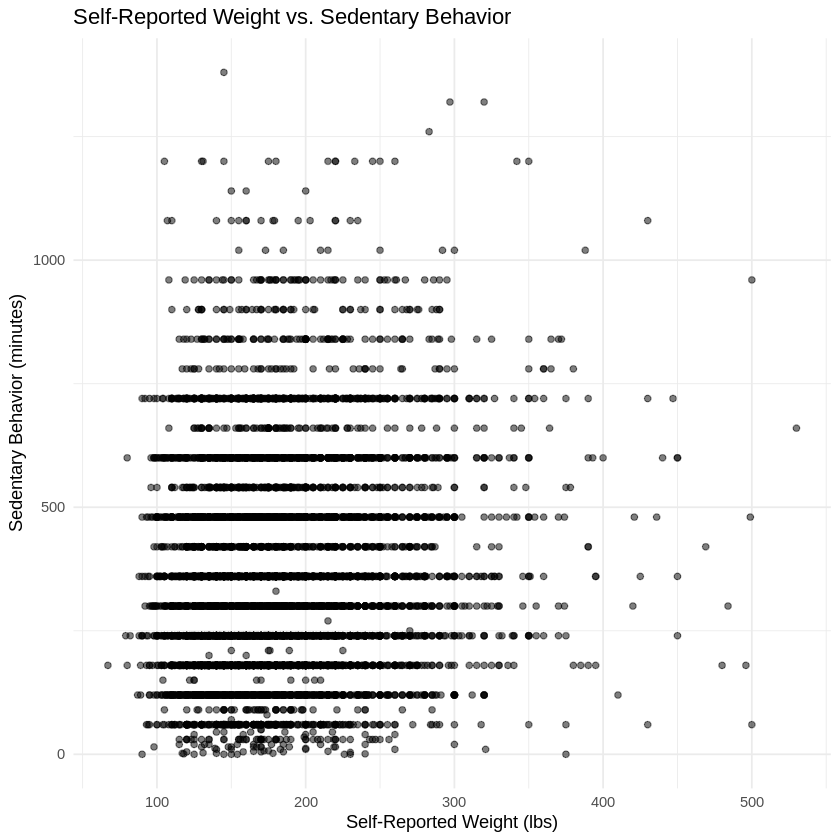

In [64]:
ggplot(correlation_data_filtered, aes(x = WHD050, y = PAD680)) +
  geom_point(alpha = 0.5) +
  labs(title = "Self-Reported Weight vs. Sedentary Behavior",
       x = "Self-Reported Weight (lbs)",
       y = "Sedentary Behavior (minutes)") +
  theme_minimal()

In [ ]:
#Question 5 (creative analysis): Is there a correlation between hepatitis B lab Antibodies (LBXHBS) and minutes of sedentary behavior?
# Load in hep b (LBXHBS) from HEPB_S_L.xpt and PAD680 from PAQ_L.xpt
# Clean data so that from current definition of (hep b, 1.0 is positive, 2.0 is negative, and 3.0 is indeterminate), data recoded so that ('negative' = 0, 'indeterminate' = 1, and 'positive' = 2).
# Clean data so that PAD680 7777 and 9999 is omitted and null is omitted
# Merge the data
# Perform Pearson correlation
# visualize

In [65]:
hepatitis_b_raw <- read_xpt('/content/HEPB_S_L.xpt')

print("Hepatitis B Raw Data (first few rows):")
print(head(hepatitis_b_raw))

print("\nSummary of LBXHBS column before cleaning:")
print(table(hepatitis_b_raw$LBXHBS, useNA = "ifany"))

[1] "Hepatitis B Raw Data (first few rows):"
# A tibble: 6 × 3
    SEQN WTPH2YR LBXHBS
   <dbl>   <dbl>  <dbl>
1 130378  56042.      2
2 130379  37436.      2
3 130380  85329.      2
4 130381      0      NA
5 130382  59639.      2
6 130386  44526.      1
[1] "\nSummary of LBXHBS column before cleaning:"

   1    2 <NA> 
2042 5324 1245 


In [66]:
hepatitis_b_cleaned <- hepatitis_b_raw %>%
  filter(!LBXHBS %in% c(7, 9)) %>%
  mutate(hepatitis_b_status_recoded = case_when(
    LBXHBS == 1 ~ 2,
    LBXHBS == 2 ~ 0,
    LBXHBS == 3 ~ 1,
    TRUE ~ NA_real_
  )) %>%
  filter(!is.na(hepatitis_b_status_recoded)) %>%
  select(SEQN, hepatitis_b_status_recoded)

print("\nHepatitis B Cleaned Data (first few rows with recoded status):")
print(head(hepatitis_b_cleaned))

print("\nCounts of Hepatitis B Status after cleaning and recoding:")
print(table(hepatitis_b_cleaned$hepatitis_b_status_recoded, useNA = "ifany"))

[1] "\nHepatitis B Cleaned Data (first few rows with recoded status):"
# A tibble: 6 × 2
    SEQN hepatitis_b_status_recoded
   <dbl>                      <dbl>
1 130378                          0
2 130379                          0
3 130380                          0
4 130382                          0
5 130386                          2
6 130387                          0
[1] "\nCounts of Hepatitis B Status after cleaning and recoding:"

   0    2 
5324 2042 


In [67]:
merged_hep_pa_data <- left_join(hepatitis_b_cleaned, physical_activity_cleaned, by = "SEQN")

print("Merged Hepatitis B and Physical Activity Data (first few rows):")
print(head(merged_hep_pa_data))
print("Dimensions of the merged data:")
print(dim(merged_hep_pa_data))

[1] "Merged Hepatitis B and Physical Activity Data (first few rows):"
# A tibble: 6 × 9
    SEQN hepatitis_b_status_reco…¹ PAD790Q PAD790U PAD800 PAD810Q PAD810U PAD820
   <dbl>                     <dbl>   <dbl> <chr>    <dbl>   <dbl> <chr>    <dbl>
1 130378                         0       3 "W"         45       3 "W"         45
2 130379                         0       4 "W"         45       3 "W"         45
3 130380                         0       1 "W"         20       0 ""          NA
4 130382                         0      NA  NA         NA      NA  NA         NA
5 130386                         2       1 "W"         30       1 "M"         30
6 130387                         0       0 ""          NA       0 ""          NA
# ℹ abbreviated name: ¹​hepatitis_b_status_recoded
# ℹ 1 more variable: PAD680 <dbl>
[1] "Dimensions of the merged data:"
[1] 7366    9


In [68]:
analysis_data_hep_pa <- merged_hep_pa_data %>%
  filter(!is.na(hepatitis_b_status_recoded) & !is.na(PAD680))

print("\nFiltered analysis data (first few rows):")
print(head(analysis_data_hep_pa %>% select(SEQN, hepatitis_b_status_recoded, PAD680)))
print("Dimensions of the filtered analysis data:")
print(dim(analysis_data_hep_pa))

[1] "\nFiltered analysis data (first few rows):"
# A tibble: 6 × 3
    SEQN hepatitis_b_status_recoded PAD680
   <dbl>                      <dbl>  <dbl>
1 130378                          0    360
2 130379                          0    480
3 130380                          0    240
4 130386                          2    180
5 130387                          0   1200
6 130390                          0    300
[1] "Dimensions of the filtered analysis data:"
[1] 5834    9


In [69]:
correlation_hep_pa_result <- cor.test(analysis_data_hep_pa$hepatitis_b_status_recoded, analysis_data_hep_pa$PAD680, method = "pearson")

print("Pearson Correlation Test Results between Hepatitis B Status and Sedentary Behavior:")
print(correlation_hep_pa_result)

[1] "Pearson Correlation Test Results between Hepatitis B Status and Sedentary Behavior:"

	Pearson's product-moment correlation

data:  analysis_data_hep_pa$hepatitis_b_status_recoded and analysis_data_hep_pa$PAD680
t = -1.3273, df = 5832, p-value = 0.1845
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.043020470  0.008286943
sample estimates:
       cor 
-0.0173782 



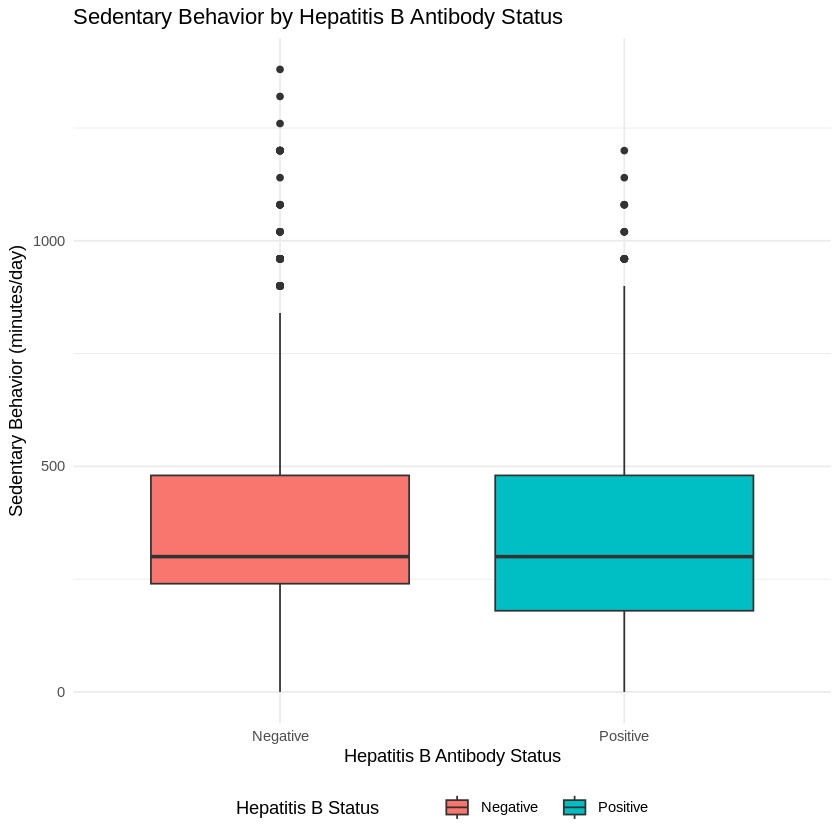

In [70]:
analysis_data_hep_pa$hepatitis_b_status_label <- factor(analysis_data_hep_pa$hepatitis_b_status_recoded,
                                                      levels = c(0, 1, 2),
                                                      labels = c("Negative", "Indeterminate", "Positive"))

ggplot(analysis_data_hep_pa, aes(x = hepatitis_b_status_label, y = PAD680, fill = hepatitis_b_status_label)) +
  geom_boxplot() +
  labs(title = "Sedentary Behavior by Hepatitis B Antibody Status",
       x = "Hepatitis B Antibody Status",
       y = "Sedentary Behavior (minutes/day)",
       fill = "Hepatitis B Status") +
  theme_minimal() +
  theme(legend.position = "bottom")